In [ ]:
import matplotlib.pyplot as plt
import numpy as np

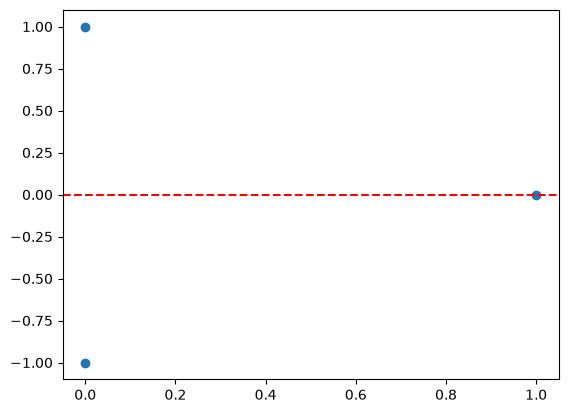

In [24]:
random_point: np.ndarray = np.array([
    [0, 1],
    [1, 0],
    [0, -1]
])

plt.scatter(random_point[:, 0], random_point[:, 1])
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Origin Line')
plt.show()

In [ ]:
from pathlib import Path
import urllib.request
import gzip
import zipfile
import numpy as np

save_dir = Path("my_custom_path/mnist")
save_dir.mkdir(parents=True, exist_ok=True)

url = "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz"
file_path = save_dir / "train-images.gz"
extracted_file_path = save_dir / "train-images-idx3-ubyte"

# 1. Download the archive if it doesn't exist
if not file_path.exists() and not extracted_file_path.exists():
    print(f"Downloading {file_path.name}...")
    urllib.request.urlretrieve(url, file_path)

# 2. Extract based on file type
if file_path.exists():
    print(f"Extracting {file_path.name}...")
    if file_path.suffix == ".gz":
        with gzip.open(file_path, "rb") as f_in:
            with open(extracted_file_path, "wb") as f_out:
                f_out.write(f_in.read())
    elif file_path.suffix == ".zip":
        with zipfile.ZipFile(file_path, "r") as zip_ref:
            zip_ref.extractall(save_dir)
            
    # Clean up compressed archive after extraction
    file_path.unlink()

# 3. Read the extracted uncompressed file
with open(extracted_file_path, "rb") as f:
    X = np.frombuffer(f.read(), dtype=np.uint8, offset=16).reshape(-1, 784)

print(X.shape)  # (60000, 784)